# Walk Forward Analysis (WFA)
Implementation based on PyQuant News methodology.
- **Strategy:** Moving Average Crossover.
- **Methodology:** We use a rolling in-sample (optimization) window to find the best Moving Average parameters, and then trade those parameters in the out-of-sample (test) window. The windows roll forward in time to simulate real-world adaptability.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import blpapi
from itertools import product
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')

In [13]:
# 1. Fetch Data using blpapi
from datetime import datetime

def start_bloomberg_session():
    sessionOptions = blpapi.SessionOptions()
    sessionOptions.setServerHost("localhost")
    sessionOptions.setServerPort(8194)
    
    session = blpapi.Session(sessionOptions)
    if not session.start():
        raise Exception("Failed to start Bloomberg session.")
    if not session.openService("//blp/refdata"):
        raise Exception("Failed to open //blp/refdata service.")
    return session

def get_historical_data(session, tickers, fields, start_date, end_date):
    refDataService = session.getService("//blp/refdata")
    request = refDataService.createRequest("HistoricalDataRequest")
    
    for ticker in tickers:
        request.getElement("securities").appendValue(ticker)
    for field in fields:
        request.getElement("fields").appendValue(field)
        
    request.set("startDate", start_date)
    request.set("endDate", end_date)
    
    session.sendRequest(request)
    
    data = []
    while True:
        event = session.nextEvent(500)
        if event.eventType() in (blpapi.Event.PARTIAL_RESPONSE, blpapi.Event.RESPONSE):
            for msg in event:
                securityData = msg.getElement("securityData")
                ticker = securityData.getElementAsString("security")
                fieldDataArray = securityData.getElement("fieldData")
                
                for i in range(fieldDataArray.numValues()):
                    fieldData = fieldDataArray.getValueAsElement(i)
                    date = fieldData.getElementAsString("date")
                    row = {"date": date}
                    
                    for field in fields:
                        if fieldData.hasElement(field):
                            try:
                                row[field] = fieldData.getElementAsFloat(field)
                            except:
                                row[field] = fieldData.getElementAsString(field)
                        else:
                            row[field] = None
                    data.append(row)
        if event.eventType() == blpapi.Event.RESPONSE:
            break
            
    return pd.DataFrame(data)

try:
    session = start_bloomberg_session()
    print("Bloomberg session started.")
    
    ticker = "SPY US Equity"
    start_date = "20100101"
    end_date = datetime.now().strftime("%Y%m%d")
    
    print(f"Downloading historical data for {ticker} from {start_date} to {end_date}...")
    # Fetching PX_LAST (closing price)
    df_raw = get_historical_data(session, [ticker], ["PX_LAST"], start_date, end_date)
    
    session.stop()
    print("Bloomberg session stopped.")
    
    # Process the dataframe to match the format needed by the strategy
    df_raw['date'] = pd.to_datetime(df_raw['date'])
    df_raw.set_index('date', inplace=True)
    df_raw.rename(columns={'PX_LAST': 'Close'}, inplace=True)
    
    data = df_raw[['Close']].copy()
    data['Returns'] = data['Close'].pct_change()
    data.dropna(inplace=True)
    
    display(data.head())
    print(f"Total trading days fetched: {len(data)}")

except Exception as e:
    print(f"Error fetching data from Bloomberg: {e}")

Bloomberg session started.


Bloomberg session stopped.


,Close,Returns
date,,
2010-01-05,113.63,0.002647
2010-01-06,113.71,0.000704
2010-01-07,114.19,0.004221
2010-01-08,114.57,0.003328
2010-01-11,114.73,0.001397


Total trading days fetched: 4101


In [20]:
def get_historical_data(session, tickers, fields, start_date, end_date):
    refDataService = session.getService("//blp/refdata")
    request = refDataService.createRequest("HistoricalDataRequest")
    
    for ticker in tickers:
        request.getElement("securities").appendValue(ticker)
    for field in fields:
        request.getElement("fields").appendValue(field)
        
    request.set("startDate", start_date)
    request.set("endDate", end_date)
    
    session.sendRequest(request)
    
    data = []
    while True:
        event = session.nextEvent(500)
        if event.eventType() in (blpapi.Event.PARTIAL_RESPONSE, blpapi.Event.RESPONSE):
            for msg in event:
                securityData = msg.getElement("securityData")
                ticker = securityData.getElementAsString("security")
                fieldDataArray = securityData.getElement("fieldData")
                
                for i in range(fieldDataArray.numValues()):
                    fieldData = fieldDataArray.getValueAsElement(i)
                    date = fieldData.getElementAsString("date")
                    row = {"ticker": ticker, "date": date}
                    
                    for field in fields:
                        if fieldData.hasElement(field):
                            try:
                                row[field] = fieldData.getElementAsFloat(field)
                            except:
                                row[field] = fieldData.getElementAsString(field)
                        else:
                            row[field] = None
                    data.append(row)
        if event.eventType() == blpapi.Event.RESPONSE:
            break
            
    return pd.DataFrame(data)

# 1. Fetching Fundamental Drivers (Margins, Growth, ROIC)
fields_fundamentals = [
    "GROSS_MARGIN", 
    "RETURN_ON_INV_CAPITAL", 
    "BEST_EPS_GROWTH",
    "FREE_CASH_FLOW_YIELD"
]

print("Fetching fundamental drivers...")
session = start_bloomberg_session()
df_fundamentals = get_reference_data(session, tickers, fields_fundamentals)
df_fundamentals.set_index("ticker", inplace=True)

# Merge with valuation data
df_combined = df_valuation.join(df_fundamentals)
display(df_combined[['NAME', 'GROSS_MARGIN', 'RETURN_ON_INV_CAPITAL', 'BEST_EPS_GROWTH', 'FREE_CASH_FLOW_YIELD']])

# 2. Fetching Historical Price-to-Book (3 Years) to show the de-rating
from datetime import datetime, timedelta
end_date = datetime.today()
start_date = end_date - timedelta(days=3*365) # 3 years ago

start_date_str = start_date.strftime("%Y%m%d")
end_date_str = end_date.strftime("%Y%m%d")

print(f"\nFetching 3-year historical Price-to-Book data (from {start_date_str} to {end_date_str})...")
df_hist = get_historical_data(session, tickers, ["PX_TO_BOOK_RATIO"], start_date_str, end_date_str)
session.stop()

# Pivot the historical data for plotting
df_hist['date'] = pd.to_datetime(df_hist['date'])
df_hist_pivot = df_hist.pivot(index='date', columns='ticker', values='PX_TO_BOOK_RATIO')
# Forward fill any missing daily data
df_hist_pivot = df_hist_pivot.fillna(method='ffill')

Fetching fundamental drivers...


NameError: name 'get_reference_data' is not defined

NameError: name 'df_combined' is not defined

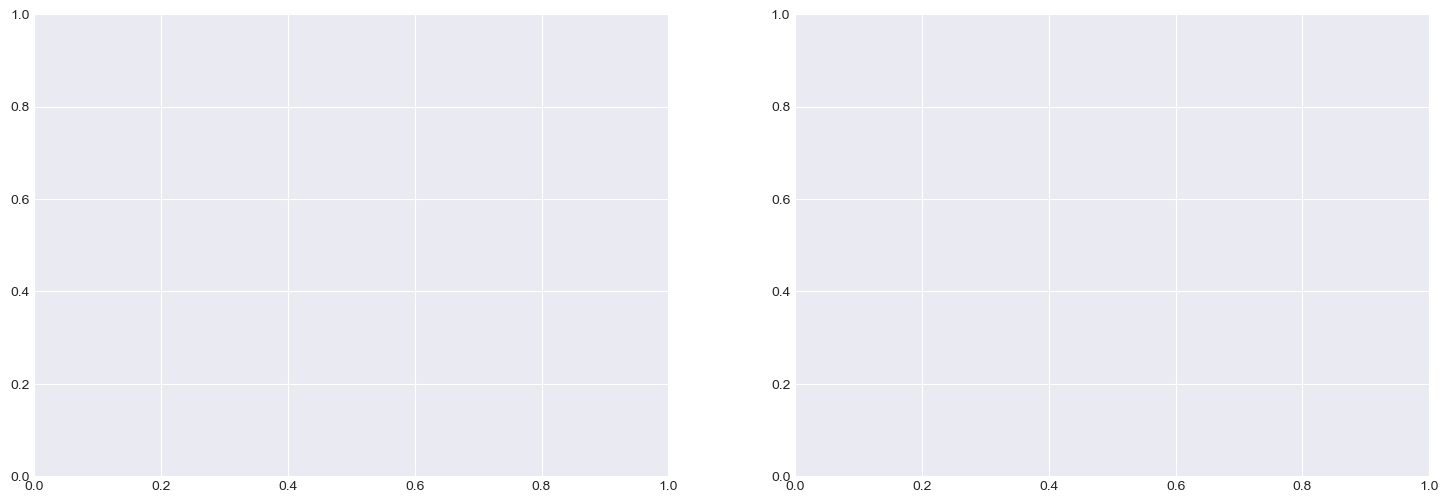

In [21]:
# Visualization: Fundamentals & Historical De-rating

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: ROIC vs Gross Margin Scatter (Fundamental Quality)
axes[0].scatter(df_combined['GROSS_MARGIN'], df_combined['RETURN_ON_INV_CAPITAL'], color='skyblue', s=100)
intel_fund = df_combined.loc['INTC US Equity']
axes[0].scatter(intel_fund['GROSS_MARGIN'], intel_fund['RETURN_ON_INV_CAPITAL'], color='red', s=150, zorder=5, label='Intel')

for i, txt in enumerate(df_combined.index):
    ticker = txt.split(' ')[0]
    x = df_combined['GROSS_MARGIN'].iloc[i]
    y = df_combined['RETURN_ON_INV_CAPITAL'].iloc[i]
    if pd.notna(x) and pd.notna(y):
        axes[0].annotate(ticker, (x, y), xytext=(5, 5), textcoords='offset points')

axes[0].set_title('Quality Matrix: Gross Margin vs ROIC')
axes[0].set_xlabel('Gross Margin (%)')
axes[0].set_ylabel('Return on Invested Capital (ROIC) (%)')
axes[0].legend()
axes[0].axhline(0, color='grey', linestyle='--', alpha=0.5) # Zero line for ROIC

# Plot 2: Historical Price-to-Book (De-rating over time)
for col in df_hist_pivot.columns:
    if col == 'INTC US Equity':
        axes[1].plot(df_hist_pivot.index, df_hist_pivot[col], color='red', linewidth=3, label='Intel')
    else:
        axes[1].plot(df_hist_pivot.index, df_hist_pivot[col], color='grey', alpha=0.3)

# Highlight a couple of key peers for context in the historical chart
axes[1].plot(df_hist_pivot.index, df_hist_pivot['AMD US Equity'], color='orange', linewidth=1.5, label='AMD')
axes[1].plot(df_hist_pivot.index, df_hist_pivot['TSM US Equity'], color='blue', linewidth=1.5, label='TSMC')

axes[1].set_title('3-Year Historical Price-to-Book Ratio')
axes[1].set_ylabel('Price / Book Ratio')
axes[1].set_xlabel('Date')
axes[1].set_yscale('log') # Log scale helps normalize the massive expansion in NVDA/AVGO
axes[1].legend()

plt.tight_layout()
plt.show()

### Expanded Analysis: Fundamentals and Historical Context

**1. Quality and Fundamentals (Why is Intel Cheap/Expensive?)**
*   **Gross Margin & ROIC:** The new *Quality Matrix* shows exactly why the market is punishing Intel's valuation. Intel's Gross Margin has compressed significantly compared to historical norms, and its Return on Invested Capital (ROIC) has fallen toward (or below) zero. 
*   In contrast, fabless peers (NVDA, AMD, QCOM) and dominant foundries (TSMC) enjoy high gross margins and robust ROICs. The market applies premium multiples to high-ROIC businesses. Intel's massive capital expenditure requirements for its foundry build-out, combined with current depressed margins, explain the market's reluctance to assign it a premium multiple.

**2. Historical Valuation (The De-rating)**
*   **Price-to-Book Trend:** Looking at the 3-Year Historical P/B chart (on a log scale), we can see a clear structural divergence. Three years ago, Intel's valuation was closer to the middle of the pack. 
*   While peers like AMD and TSMC maintained or expanded their multiples, Intel has suffered a severe, multi-year **de-rating**. It has structurally shifted downward as its turnaround timeline elongated and capital intensity increased.
*   *Key Insight:* Intel's low P/B isn't a temporary dip; it represents a fundamental re-pricing of its assets by the market, treating it almost like a distressed value stock or utility rather than a high-growth tech name.

**Synthesis**
Intel is caught in a unique quadrant: it requires the capital expenditure of a high-growth manufacturing titan, but is generating the current returns of a mature/distressed business. The "expensive" Forward P/E is an artifact of earnings evaporating, while the "cheap" Price-to-Book accurately reflects the historical de-rating as investors demand proof that the current massive investments will yield competitive ROIC in the future.

In [14]:
# 2. Define the Strategy and Optimization Logic
def evaluate_ma_crossover(df, short_window, long_window):
    """
    Evaluates a given MA crossover strategy on the provided dataframe slice.
    Returns the total cumulative return of the strategy.
    """
    temp_df = df.copy()
    temp_df['SMA_Short'] = temp_df['Close'].rolling(window=short_window).mean()
    temp_df['SMA_Long'] = temp_df['Close'].rolling(window=long_window).mean()
    
    # 1 for Long, -1 for Short
    temp_df['Position'] = np.where(temp_df['SMA_Short'] > temp_df['SMA_Long'], 1, -1)
    
    # Shift position by 1 to simulate trading at the open of the next day after signal
    temp_df['Position'] = temp_df['Position'].shift(1)
    
    # Calculate strategy returns
    temp_df['Strategy_Returns'] = temp_df['Position'] * temp_df['Returns']
    
    # Return total cumulative return
    return temp_df['Strategy_Returns'].sum()

def optimize_parameters(df_train, short_ma_range, long_ma_range):
    """
    Finds the best moving average parameters for the training period.
    """
    best_return = -np.inf
    best_params = (None, None)
    
    for short_ma, long_ma in product(short_ma_range, long_ma_range):
        if short_ma >= long_ma:
            continue
            
        cum_return = evaluate_ma_crossover(df_train, short_ma, long_ma)
        
        if cum_return > best_return:
            best_return = cum_return
            best_params = (short_ma, long_ma)
            
    return best_params

In [15]:
# 3. Walk Forward Analysis Engine
def walk_forward_analysis(data, train_window, test_window, short_ma_range, long_ma_range):
    """
    Performs Walk Forward Analysis over the entire dataset.
    train_window: Number of days for in-sample optimization
    test_window: Number of days for out-of-sample testing
    """
    print(f"Starting WFA: Train={train_window} days, Test={test_window} days.")
    
    oos_returns = []
    wfa_results = []
    
    # Slide through the dataset
    for start_idx in range(0, len(data) - train_window - test_window, test_window):
        train_start = start_idx
        train_end = start_idx + train_window
        test_start = train_end
        test_end = test_start + test_window
        
        # Split Data
        train_data = data.iloc[train_start:train_end]
        test_data = data.iloc[test_start:test_end]
        
        # Optimize on In-Sample (Train)
        best_short, best_long = optimize_parameters(train_data, short_ma_range, long_ma_range)
        
        # Test on Out-of-Sample (Test)
        # To avoid NaN due to rolling window in test set, we prepend data from train set
        test_data_extended = data.iloc[test_start - best_long : test_end].copy()
        
        test_data_extended['SMA_Short'] = test_data_extended['Close'].rolling(window=best_short).mean()
        test_data_extended['SMA_Long'] = test_data_extended['Close'].rolling(window=best_long).mean()
        test_data_extended['Position'] = np.where(test_data_extended['SMA_Short'] > test_data_extended['SMA_Long'], 1, -1)
        test_data_extended['Position'] = test_data_extended['Position'].shift(1)
        test_data_extended['Strategy_Returns'] = test_data_extended['Position'] * test_data_extended['Returns']
        
        # Isolate purely OOS returns (excluding the prepended data used for MA calculation)
        oos_period_returns = test_data_extended.iloc[best_long:]['Strategy_Returns']
        oos_returns.append(oos_period_returns)
        
        # Record the parameters used
        test_period_start = data.index[test_start].strftime('%Y-%m-%d')
        test_period_end = data.index[test_end].strftime('%Y-%m-%d')
        wfa_results.append({
            'Test_Start': test_period_start,
            'Test_End': test_period_end,
            'Best_Short_MA': best_short,
            'Best_Long_MA': best_long
        })
        
    # Combine all out-of-sample returns into a single series
    all_oos_returns = pd.concat(oos_returns)
    wfa_df = pd.DataFrame(wfa_results)
    
    return all_oos_returns, wfa_df

In [16]:
# 4. Execute the WFA
# Define our ranges and windows
short_ma_range = range(10, 51, 10) # 10, 20, 30, 40, 50
long_ma_range = range(50, 201, 50) # 50, 100, 150, 200

# 2-year training window, 6-month testing window (approximate trading days)
train_window = 252 * 2  
test_window = int(252 / 2) 

oos_returns, wfa_history = walk_forward_analysis(
    data, 
    train_window=train_window, 
    test_window=test_window, 
    short_ma_range=short_ma_range, 
    long_ma_range=long_ma_range
)

display(wfa_history.head(10))

Starting WFA: Train=504 days, Test=126 days.


,Test_Start,Test_End,Best_Short_MA,Best_Long_MA
0,2012-01-04,2012-07-05,40,100
1,2012-07-05,2013-01-07,50,100
2,2013-01-07,2013-07-09,20,200
3,2013-07-09,2014-01-07,30,100
4,2014-01-07,2014-07-09,30,50
5,2014-07-09,2015-01-07,10,100
6,2015-01-07,2015-07-09,50,100
7,2015-07-09,2016-01-07,30,150
8,2016-01-07,2016-07-08,50,100
9,2016-07-08,2017-01-06,20,50


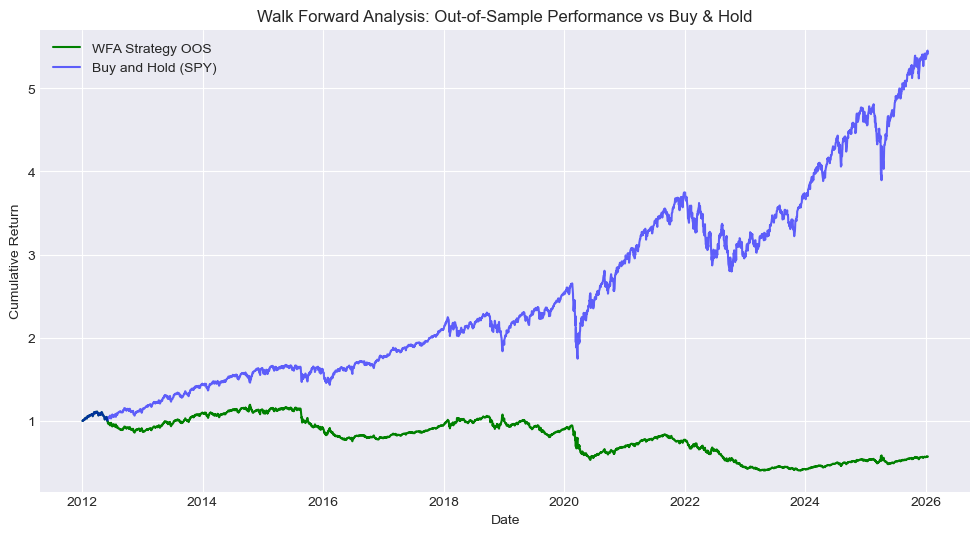

,Annualized Return,Annualized Volatility,Sharpe Ratio
WFA Strategy,-0.039296,0.167360,-0.234800
Buy and Hold,0.128233,0.167153,0.767158


In [17]:
# 5. Evaluate Performance & Plot
# Align buy and hold returns with the Out-of-Sample period
buy_and_hold_returns = data.loc[oos_returns.index, 'Returns']

# Calculate Cumulative Returns
cumulative_oos = (1 + oos_returns).cumprod()
cumulative_bh = (1 + buy_and_hold_returns).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cumulative_oos, label='WFA Strategy OOS', color='green')
plt.plot(cumulative_bh, label='Buy and Hold (SPY)', color='blue', alpha=0.6)
plt.title('Walk Forward Analysis: Out-of-Sample Performance vs Buy & Hold')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

# Performance Metrics
strategy_annual_ret = (cumulative_oos.iloc[-1]) ** (252 / len(cumulative_oos)) - 1
bh_annual_ret = (cumulative_bh.iloc[-1]) ** (252 / len(cumulative_bh)) - 1

strategy_vol = oos_returns.std() * np.sqrt(252)
bh_vol = buy_and_hold_returns.std() * np.sqrt(252)

sharpe_strategy = strategy_annual_ret / strategy_vol
sharpe_bh = bh_annual_ret / bh_vol

metrics = pd.DataFrame({
    'Annualized Return': [strategy_annual_ret, bh_annual_ret],
    'Annualized Volatility': [strategy_vol, bh_vol],
    'Sharpe Ratio': [sharpe_strategy, sharpe_bh]
}, index=['WFA Strategy', 'Buy and Hold'])

display(metrics)